# Neural Network

In [74]:
# pylint: disable=missing-module-docstring
import math
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt

from abc import abstractmethod
from typing import Tuple

np.random.seed(42)

## Load Data

In [160]:
def print_score(p_hat: NDArray, y: NDArray):
    # pylint: disable=missing-function-docstring
    tp = np.sum(np.logical_and(p_hat == 1, y == 1))
    fp = np.sum(np.logical_and(p_hat == 1, y == 0))
    tn = np.sum(np.logical_and(p_hat == 0, y == 0))
    fn = np.sum(np.logical_and(p_hat == 0, y == 1))
    accuracy = (tp + tn) / (tp + fp + tn + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print('==== Score ====')
    print(f'Y: positive counter: {np.sum(y == 1)}, negative counter: {np.sum(y == 0)}')
    print(f'Accuracy: {(tp + tn) / (tp + fp + tn + fn):.4f}')
    print(f'TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'Accuracy: {accuracy:.4f}')
    print(f'F1 Score: {f1:.4f}')

def load_data_npy():
    # pylint: disable=missing-function-docstring
    x = np.load("data/X.npy")
    y = np.load("data/y.npy")
    return x, y

def shuffle_data(x: NDArray, y: NDArray, m: int) -> Tuple[NDArray, NDArray]:
    # pylint: disable=missing-function-docstring
    indices = np.random.choice(x.shape[0], m, replace=False)
    return x[indices], y[indices]

def split_data(x: NDArray, y: NDArray, rate: float) -> Tuple[NDArray, NDArray, NDArray, NDArray]:
    # pylint: disable=missing-function-docstring
    m = x.shape[0]
    indices = np.random.permutation(m)
    m_sp = int(m * rate)
    m_train = indices[:m_sp]
    m_test = indices[m_sp:]
    return x[m_train], x[m_test], y[m_train], y[m_test]

x_data, y_data = load_data_npy()
# x_data, y_data = shuffle_data(x_data, y_data, 1000)
x_train, x_test, y_train, y_test = split_data(x_data, y_data, 0.8)
# x_train = x_data
# x_test = x_data
# y_train = y_data
# y_test = y_data

print (f'Shape: x_data {x_data.shape}, y_data {y_data.shape}')
print (f'Shape: x_train {x_train.shape}, y_train {y_train.shape}')
print (f'Shape: x_test {x_test.shape}, y_test {y_test.shape}')
# print ('The first element of x is: ', x_train[0])

Shape: x_data (5000, 400), y_data (5000, 1)
Shape: x_train (4000, 400), y_train (4000, 1)
Shape: x_test (1000, 400), y_test (1000, 1)


## Visualizate the data

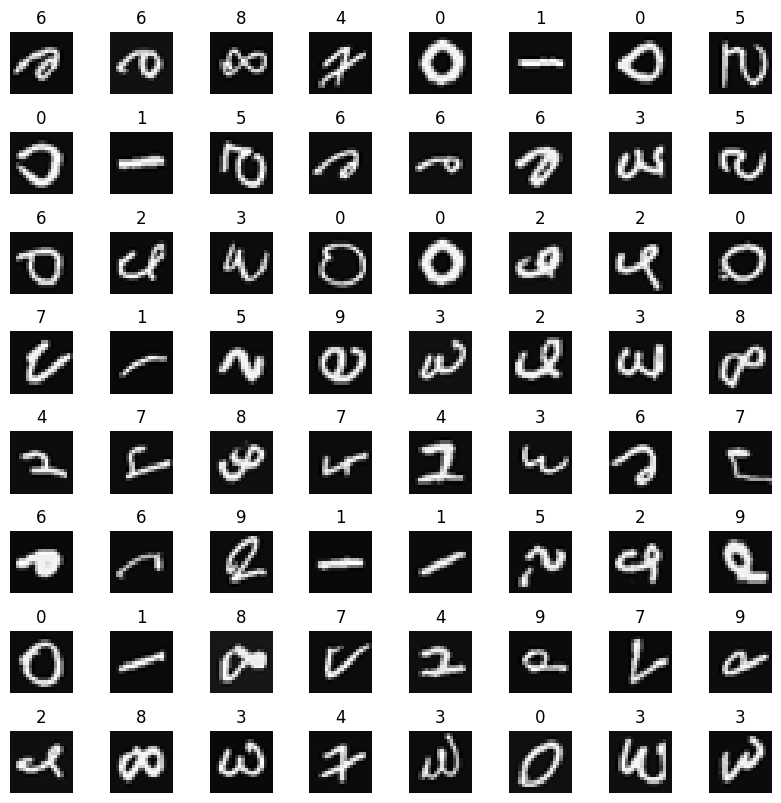

In [88]:
def visualize_data(x: NDArray, y: NDArray):
    # pylint: disable=missing-function-docstring
    m, _ = x.shape

    fig, axes = plt.subplots(8,8, figsize=(8,8))
    fig.tight_layout(pad=0.1)

    for _,ax in enumerate(axes.flat):
        # Select random indices
        random_index = np.random.randint(m)
        
        # Select rows corresponding to the random indices and
        # reshape the image
        x_random_reshaped = x[random_index].reshape((20,20))
        
        # Display the image
        ax.imshow(x_random_reshaped, cmap='gray')
        
        # Display the label above the image
        ax.set_title(y[random_index,0])
        ax.set_axis_off()

visualize_data(x_train, y_train)

## Activation Functions

In [161]:
class ActivationFunction:
    # pylint: disable=missing-class-docstring

    def __init__(self):
        # pylint: disable=missing-function-docstring
        pass

    def forward(self, x, w, b) -> NDArray:
        # pylint: disable=missing-function-docstring
        z = np.dot(x, w) + b
        return self.activation(z)

    @abstractmethod
    def activation(self, z: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        pass

    @abstractmethod
    def derivative(self, a: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        pass

class LinearActivation(ActivationFunction):
    # pylint: disable=missing-class-docstring

    def activation(self, z: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        return z

    def derivative(self, a: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        return np.ones_like(a)

class SigmoidActivation(ActivationFunction):
    # pylint: disable=missing-class-docstring

    def activation(self, z: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        z = np.clip(z, -500, 500)
        g = 1 / (1 + np.exp(-z))
        return g

    def derivative(self, a: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        return a * (1 - a)

class ReluActivation(ActivationFunction):
    # pylint: disable=missing-class-docstring

    def activation(self, z: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        return np.maximum(0, z)

    def derivative(self, a: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        return np.where(a > 0, 1, 0)

class SoftmaxActivation(ActivationFunction):
    # pylint: disable=missing-class-docstring

    def activation(self, z: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        ez = np.exp(z - np.max(z, axis=1, keepdims=True))
        sm = ez / np.sum(ez, axis=1, keepdims=True)
        return sm
    
    def derivative(self, a: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        # Work with SparseCategoricalCrossentropy
        return a;

## Loss Functions

In [197]:
class LossFunction:
    # pylint: disable=missing-class-docstring
    
    @abstractmethod
    def compute_loss(self, p_hat: NDArray, y: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        pass

    @abstractmethod
    def derivative(self, p_hat: NDArray, y: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        pass


class BinaryCrossEntropy(LossFunction):
    # pylint: disable=missing-class-docstring

    def compute_loss(self, p_hat: NDArray, y: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        epsilon = 1e-7
        p_hat_clipped = np.clip(p_hat, epsilon, 1. - epsilon)
        loss = -(y * np.log(p_hat_clipped) + (1 - y) * np.log(1 - p_hat_clipped))
        return loss

    def derivative(self, p_hat: NDArray, y: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        eps = 1e-7
        p_hat_clipped = np.clip(p_hat, eps, 1.0 - eps)
        return (p_hat_clipped - y) / (p_hat_clipped * (1 - p_hat_clipped))

class SparseCategoricalCrossentropy(LossFunction):
    # pylint: disable=missing-class-docstring
    def compute_loss(self, p_hat: NDArray, y: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        epsilon = 1e-7
        p_hat_clipped = np.clip(p_hat, epsilon, 1. - epsilon)
        y_flat = y.flatten()
        loss = -np.log(p_hat_clipped[np.arange(len(y_flat)), y_flat])
        return loss
    
    def derivative(self, p_hat: NDArray, y: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        batch_size = p_hat.shape[0]
        dz = p_hat.copy()
        y_flat = y.flatten()
        dz[np.arange(batch_size), y_flat] -= 1.0
        dz /= batch_size
        return dz

## Optimized Function

In [211]:
class Optimizer:
    # pylint: disable=missing-class-docstring
    def __init__(self, learning_rate: float):
        self.params = []
        self.learning_rate = learning_rate
    
    @abstractmethod
    def init_param(self, params: list):
        pass

    @abstractmethod
    def step(self, grads):
        pass

class AdamOptimizer(Optimizer):
    # pylint: disable=missing-class-docstring
    """Adam 优化器实现"""
    def __init__(self, learning_rate=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
        """
        初始化 Adam 优化器。
        
        参数:
            params: 需要优化的参数列表，例如 [(w1, b1), (w2, b2), ...]。
            learning_rate: 学习率。
            beta1: 一阶矩估计的衰减率。
            beta2: 二阶矩估计的衰减率。
            epsilon: 防止除以零的极小值。
        """
        super().__init__(learning_rate) 
        self.beta1 = beta1  
        self.beta2 = beta2
        self.epsilon = epsilon     
        # 为每个参数初始化一阶矩 (m) 和二阶矩 (v)
        self.params = []
        self.m = []
        self.v = []
        self.t = 0 # 时间步

    def init_param(self, params: list):
        self.params = params
        self.m = [np.zeros_like(p) for p in params]
        self.v = [np.zeros_like(p) for p in params]

    def step(self, grads):
        """
        执行一步参数更新。
        
        参数:
            grads: 与 params 对应的梯度列表。
        """
        self.t += 1
        
        for i, (param, grad) in enumerate(zip(self.params, grads)):
            # 1. 更新一阶矩估计
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * grad
            
            # 2. 更新二阶矩估计
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (grad ** 2)
            
            # 3. 偏差修正
            m_hat = self.m[i] / (1 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1 - self.beta2 ** self.t)
            
            # 4. 更新参数
            param -= self.learning_rate * m_hat / (np.sqrt(v_hat) + self.epsilon)

class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4, restore_best_weights=True, verbose=False):
        """
        早停机制实现
        :param patience: 容忍多少个epoch没有改善
        :param min_delta: 最小改善幅度，小于这个值视为没有改善
        :param restore_best_weights: 是否恢复到最佳状态
        :param verbose: 是否打印日志
        """
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.verbose = verbose
        
        # 内部状态
        self.counter = 0             # 计数器
        self.best_loss = None        # 历史最佳 Loss
        self.early_stop = False      # 停止标志
        self.best_params = None      # 用于保存最佳权重（如果是回滚模式）

    def step(self, current_loss, model_params):
        """
        每个 epoch 结束后调用一次
        :param current_loss: 当前的 cost
        :param model_params: 当前模型的所有参数列表 (引用)
        """
        
        # 1. 初始化或判断是否改善
        if self.best_loss is None:
            self.best_loss = current_loss
            self.counter = 0
            if self.restore_best_weights:
                self.best_params = [p.copy() for p in model_params] # 深度拷贝
        elif current_loss > self.best_loss - self.min_delta:
            # 当前 Loss 没有比最佳 Loss 减去 min_delta 更小，视为“没有改善”
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter}/{self.patience} | Loss: {current_loss:.6f}")
            
            # 2. 检查是否超过容忍度
            if self.counter >= self.patience:
                self.early_stop = True
                if self.verbose:
                    print(f"Early stopping triggered at loss {current_loss:.6f}")
        else:
            # 3. 有改善，重置状态
            if self.verbose:
                print(f"Loss improved from {self.best_loss:.6f} to {current_loss:.6f}")
            self.best_loss = current_loss
            self.counter = 0
            if self.restore_best_weights:
                # 更新最佳参数备份
                self.best_params = [p.copy() for p in model_params]

    def apply_best_weights(self, model_params):
        """
        如果开启了回滚，将最佳权重写回模型
        """
        if self.restore_best_weights and self.best_params is not None:
            for i, param in enumerate(model_params):
                # 直接修改数组内容，保持引用关系不变
                param[:] = self.best_params[i]
            if self.verbose:
                print("Restored weights to best epoch.")

## Neural Network

In [228]:
class NeuralLayer:
    # pylint: disable=missing-class-docstring

    def __init__(self, name: str, dim_in: int, dim_out: int, act_function: ActivationFunction, lambda_: float = 0):
        # pylint: disable=missing-function-docstring
        self.name = name
        self.dim_in = dim_in
        self.dim_out = dim_out
        self.act_function = act_function
        # self.lr = lr
        self.lambda_ = lambda_
        self.a_in = np.zeros(1)
        self.a_out = np.zeros(1)
        self.init_weights(dim_in, dim_out)
    
    def init_weights(self, dim_in: int, dim_out: int):
        # pylint: disable=missing-function-docstring
        std_dev = np.sqrt(2.0 / dim_in)
        self.w = np.random.randn(dim_in, dim_out) * std_dev
        self.b = np.zeros(dim_out)
        self.dj_dw = np.zeros(self.w.shape)
        self.dj_db = np.zeros(self.b.shape)
    
    def weights(self) -> Tuple[NDArray, NDArray]:
        # pylint: disable=missing-function-docstring
        return self.w, self.b
    
    def gradients(self) -> Tuple[NDArray, NDArray]:
        # pylint: disable=missing-function-docstring
        return self.dj_dw, self.dj_db

    def forward(self, a: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        self.a_in = a
        self.a_out = self.act_function.forward(self.a_in, self.w, self.b)
        return self.a_out
    
    def backward(self, da: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring

        dz = da * self.act_function.derivative(self.a_out)

        m = self.a_in.shape[0]
        self.dj_dw = np.dot(self.a_in.T, dz) / m
        if self.lambda_ != 0:
            self.dj_dw += (self.lambda_ / m) * self.w
        self.dj_db = np.sum(dz, axis = 0) / m
        # self.w -= self.lr * dj_dw
        # self.b -= self.lr * dj_db        
        
        
        bwd_dz = np.dot(dz, self.w.T)
        # print(f'shape: dz {dz.shape}, w {self.w.shape}, dj_dw {dj_dw.shape}, b {self.b.shape}, dj_db {dj_db.shape}， bwd_dz {bwd_dz.shape}')
        return bwd_dz

class NeuralNetwork:
    # pylint: disable=missing-class-docstring

    def __init__(self, x_train: NDArray, y_train: NDArray, epochs: int,loss_function: LossFunction, optimizer: Optimizer, early_stopping: EarlyStopping):
        self.x, self.y = x_train, y_train
        self.epochs = epochs
        self.layers: list[NeuralLayer] = []
        self.loss_function = loss_function
        self.optimizer = optimizer
        self.early_stopping = early_stopping
    
    def add_layer(self, layer: NeuralLayer):
        # pylint: disable=missing-function-docstring
        self.layers.append(layer)
        params = []
        for layer in self.layers:
            w, b = layer.weights()
            params.append(w)
            params.append(b)
        self.optimizer.init_param(params)
    
    def get_layers(self) -> list[NeuralLayer]:
        # pylint: disable=missing-function-docstring
        return self.layers

    def compute_cost(self, lambda_: float = 0) -> Tuple[float, NDArray]:
        # pylint: disable=missing-function-docstring

        if (len(self.layers) == 0):
            return 0., np.zeros(0)

        loss = self.loss_function.compute_loss(self.p_hat, self.y)
        cost_without_reg = np.mean(loss)

        reg_cost = 0
        w_num = 0
        for layer in self.layers:
            w, _ = layer.weights()
            if lambda_ != 0:
                reg_cost += np.sum(np.square(w.flatten()))
            w_num += w.shape[1]

        cost = cost_without_reg if lambda_ == 0 else (cost_without_reg + (lambda_ / (2 * w_num)) * reg_cost)
        return cost, loss

    def forward(self, x: NDArray) -> NDArray:
        # pylint: disable=missing-function-docstring
        a = x
        for layer in self.layers:
            a = layer.forward(a)
        
        return a
    
    def backward(self):
        # pylint: disable=missing-function-docstring
        da = self.loss_function.derivative(self.p_hat, self.y)
        for layer in reversed(self.layers):
            da = layer.backward(da)
        
        grads = []
        for layer in self.layers:
            dj_dw, dj_db = layer.gradients()
            grads.append(dj_dw)
            grads.append(dj_db)
        self.optimizer.step(grads)

    def fit(self, cost_lambda: float = 0) -> Tuple[float, NDArray]:
        # pylint: disable=missing-function-docstring
        print_num = 20
        num_prints = max(1, math.ceil(self.epochs / print_num))
        for i in range(self.epochs):
            self.p_hat = self.forward(self.x)
            cost, loss = self.compute_cost(cost_lambda)
            self.early_stopping.step(cost, self.optimizer.params)
            if self.early_stopping.early_stop:
                print(f"Training stopped early at epoch {i+1}.")
                self.early_stopping.apply_best_weights(self.optimizer.params)
                break

            idx = i+1
            if idx % num_prints == 0:
                print(f'Epoch {idx:10d}: Cost {cost:.8f}')
            nn.backward()
        return cost,loss

    def predict(self, x) -> NDArray:
        # pylint: disable=missing-function-docstring
        p_hat = self.forward(x)
        return p_hat
        
def plot_data(x, y, pos_label="y=1", neg_label="y=0"):
    # pylint: disable=missing-function-docstring
    positive = y == 1
    negative = y == 0
    # Plot examples
    plt.plot(x[positive, 0], y[positive], 'k+', label=pos_label)
    plt.plot(x[negative, 0], y[negative], 'yo', label=neg_label)

# test_neural_network()
nn = NeuralNetwork(x_train, y_train, 1000, SparseCategoricalCrossentropy(), AdamOptimizer(), EarlyStopping(min_delta=1e-4))
lambda_ = 0
nn.add_layer(NeuralLayer('Layer 1', 400, 25, ReluActivation(), lambda_))
nn.add_layer(NeuralLayer('Layer 2', 25, 15, ReluActivation(), lambda_))
nn.add_layer(NeuralLayer('Layer 3', 15, 10, SoftmaxActivation(), lambda_))
nn.fit()

Epoch         50: Cost 1.70518181
Epoch        100: Cost 1.31422484
Epoch        150: Cost 0.87039952
Epoch        200: Cost 0.53686765
Epoch        250: Cost 0.47462704
Epoch        300: Cost 0.46106497
Training stopped early at epoch 304.


(0.46333721538651984,
 array([0.00232601, 0.00276026, 0.01687705, ..., 0.00045307, 0.00922322,
        0.21985622]))

## Inference

shape: p_hat (1000, 10), y (1000, 1)
Accuracy: 0.847


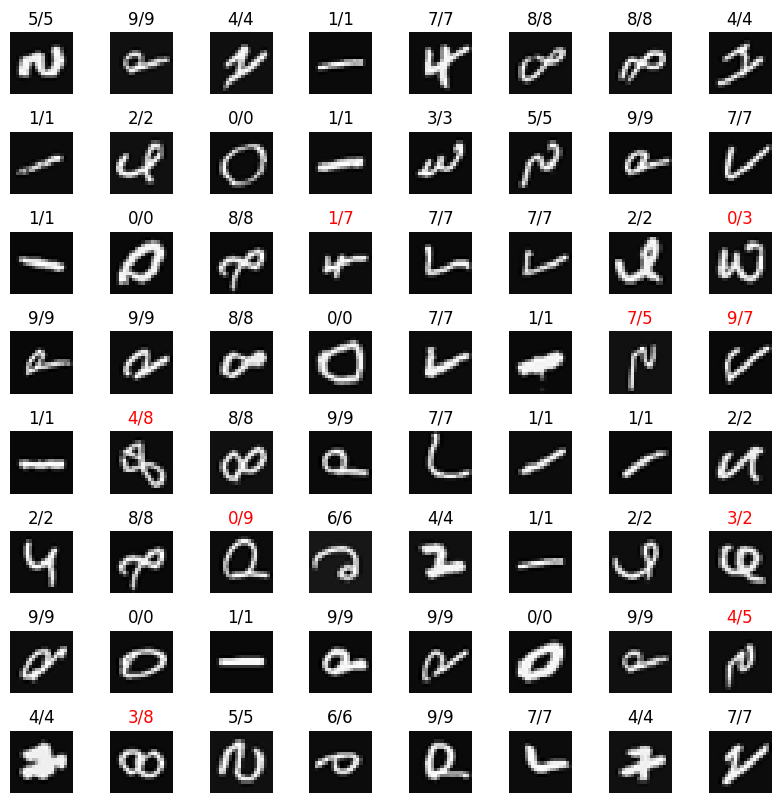

In [229]:
def test_predict(nn: NeuralNetwork,x: NDArray, y: NDArray):
    # pylint: disable=missing-function-docstring
    p_hat = nn.predict(x)
    print(f'shape: p_hat {p_hat.shape}, y {y.shape}')
    p = np.argmax(p_hat, axis=1)
    
    # print_score(p, y)
    print(f'Accuracy: {np.mean(p == y[:,0]):.3f}')

    m, _ = x.shape
    fig, axes = plt.subplots(8,8, figsize=(8,8))
    fig.tight_layout(pad=0.1)
    for _,ax in enumerate(axes.flat):
        # Select random indices
        random_index = np.random.randint(m)
        
        # Select rows corresponding to the random indices and
        # reshape the image
        x_random_reshaped = x[random_index].reshape((20,20))
        
        # Display the image
        ax.imshow(x_random_reshaped, cmap='gray')
        
        # Display the label above the image
        ax.set_title(
            f'{p[random_index]}/{y[random_index,0]}',
            color = f'{'black' if p[random_index] == y[random_index,0] else 'red'}'
        )
        ax.set_axis_off()

test_predict(nn, x_test, y_test)
